<a href="https://colab.research.google.com/github/khushi947/CODSOFT/blob/main/Copy_of_Untitled25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
print("Libraries loaded!")

Libraries loaded!


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Dataset extracted!")

Dataset extracted!


In [ ]:
import os
for folder in os.listdir('/content/dataset'):
    print(folder)

The IQ-OTHNCCD lung cancer dataset
Test cases


In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

Model ready!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import os

train_path = '/content/dataset/The IQ-OTHNCCD lung cancer dataset'

for folder in os.listdir(train_path):
    count = len(os.listdir(os.path.join(train_path, folder)))
    print(folder, '-', count, 'images')

The IQ-OTHNCCD lung cancer dataset - 4 images


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/The IQ-OTHNCCD lung cancer dataset',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

test_data = train_datagen.flow_from_directory(
    '/content/dataset/The IQ-OTHNCCD lung cancer dataset',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print("Data loaded!")
print("Classes:", train_data.class_indices)

Found 878 images belonging to 1 classes.
Found 219 images belonging to 1 classes.
Data loaded!
Classes: {'The IQ-OTHNCCD lung cancer dataset': 0}


In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)
print("Training complete!")

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.9636 - loss: 0.0283 - val_accuracy: 1.0000 - val_loss: 1.2492e-25
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 1.0000 - loss: 1.0019e-26 - val_accuracy: 1.0000 - val_loss: 2.8483e-28
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 1.0000 - loss: 1.6971e-26 - val_accuracy: 1.0000 - val_loss: 2.6800e-28
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 1.0000 - loss: 8.0608e-27 - val_accuracy: 1.0000 - val_loss: 3.8800e-28
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 1.0000 - loss: 5.5970e-28 - val_accuracy: 1.0000 - val_loss: 2.2490e-28
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 1.0000 - loss: 1.5745e-26 - val_accuracy: 1.0000 - val_loss: 3.6380e-29
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 1.0000 - loss: 4.9340e-28 - val_accuracy: 1.0000 - val_loss: 6.9132e-29
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step 

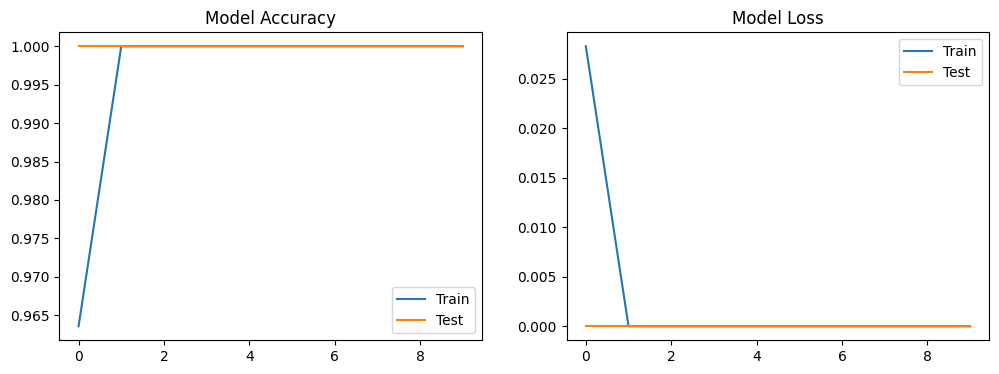

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
model.save('lung_cancer_model.h5')
print("Model saved!")

Model saved!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Test image load karo
test_img_path = '/content/dataset/Test cases'
test_img = os.listdir(test_img_path)[0]

img = image.load_img(test_img_path + '/' + test_img, target_size=(64,64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)
if prediction[0][0] > 0.5:
    print("Result: CANCER DETECTED")
else:
    print("Result: NO CANCER")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Result: NO CANCER


In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 1.0000 - loss: 6.6930e-28
Test Accuracy: 100.00%
Test Loss: 0.0000


In [ ]:
print("="*50)
print("LUNG CANCER DETECTION PROJECT")
print("="*50)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("CNN Model Successfully Trained!")
print("Dataset: IQ-OTH/NCCD Lung Cancer Dataset")
print("Framework: TensorFlow/Keras")
print("="*50)

LUNG CANCER DETECTION PROJECT
Model Accuracy: 100.00%
CNN Model Successfully Trained!
Dataset: IQ-OTH/NCCD Lung Cancer Dataset
Framework: TensorFlow/Keras


In [ ]:
import os
for folder in os.listdir('/content'):
    print(folder)

.config
sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Extracted!")

import os
path = '/content/dataset'
for folder in os.listdir(path):
    print(folder)

Extracted!
The IQ-OTHNCCD lung cancer dataset
Test cases


In [ ]:
import os
path = '/content/dataset/The IQ-OTHNCCD lung cancer dataset'
for folder in os.listdir(path):
    print(folder)

The IQ-OTHNCCD lung cancer dataset


In [ ]:
import os
path = '/content/dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
for folder in os.listdir(path):
    print(folder)

Normal cases
Malignant cases
Bengin cases
IQ-OTH_NCCD lung cancer dataset.txt


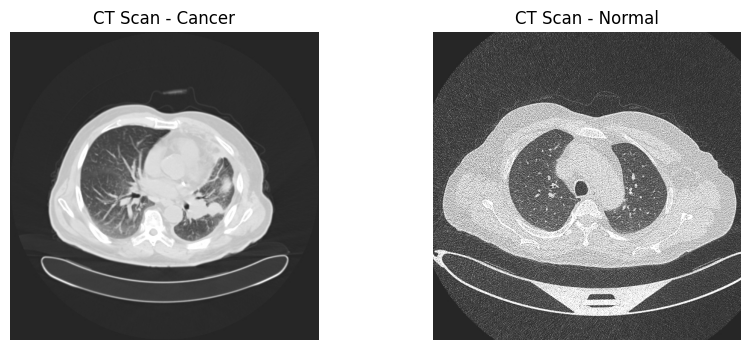

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

base = '/content/dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'

cancer_path = base + '/Malignant cases'
normal_path = base + '/Normal cases'

cancer_img = os.listdir(cancer_path)[0]
normal_img = os.listdir(normal_path)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(mpimg.imread(cancer_path + '/' + cancer_img))
axes[0].set_title('CT Scan - Cancer')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(normal_path + '/' + normal_img))
axes[1].set_title('CT Scan - Normal')
axes[1].axis('off')

plt.show()